In [1]:
!pip -q install qiskit qiskit-aer matplotlib pennylane ipywidgets pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 

Demo 1 – Visualizing a Qubit on the Bloch Sphere

A qubit is often represented using the Bloch Sphere, where each point on the sphere corresponds to a unique quantum state. In this demo, we'll visualize the default state of a qubit before applying any quantum gates.

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt

def show_bloch(gate):

    qc = QuantumCircuit(1)

    if gate == "X":
        qc.x(0)
    elif gate == "Y":
        qc.y(0)
    elif gate == "Z":
        qc.z(0)
    elif gate == "H":
        qc.h(0)

    state = Statevector.from_instruction(qc)

    plt.close('all')          # Clear previous figures
    fig = plot_bloch_multivector(state)
    display(fig)

widgets.interact(
    show_bloch,
    gate=["None", "X", "Y", "Z", "H"]
)

interactive(children=(Dropdown(description='gate', options=('None', 'X', 'Y', 'Z', 'H'), value='None'), Output…

<function __main__.show_bloch(gate)>

Demo 2 – Quantum Gates on the Bloch Sphere

Quantum gates don't simply change 0 to 1. Instead, they rotate the qubit's state on the Bloch Sphere. In this demo, we'll apply different quantum gates and observe how the Bloch vector changes.

Available Gates
1. None
2. X
3. Y
4. Z
5. H

Choose a gate: h

Quantum Circuit


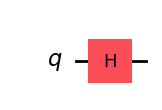


Bloch Sphere


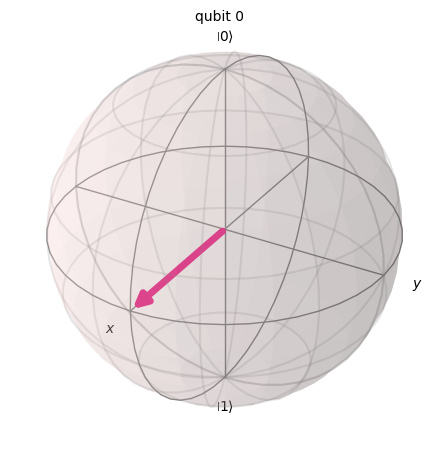

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

print("Available Gates")
print("1. None")
print("2. X")
print("3. Y")
print("4. Z")
print("5. H")

choice = input("\nChoose a gate: ").strip().upper()

qc = QuantumCircuit(1)

if choice == "X":
    qc.x(0)
elif choice == "Y":
    qc.y(0)
elif choice == "Z":
    qc.z(0)
elif choice == "H":
    qc.h(0)

print("\nQuantum Circuit")
display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)

print("\nBloch Sphere")
display(plot_bloch_multivector(state))

Demo 3 – Measurement Statistics

Quantum measurements are probabilistic. Running the same circuit multiple times allows us to estimate the probabilities of different outcomes. In this demo, we'll compare the results obtained using different numbers of shots.

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

sim = AerSimulator()

for shots in [1, 10, 100, 1000]:

    qc = QuantumCircuit(1,1)

    qc.x(0)

    qc.measure(0,0)

    result = sim.run(qc, shots=shots).result()

    counts = result.get_counts()

    print(f"Shots = {shots}")

    print(counts)

    print("-"*30)

Shots = 1
{'1': 1}
------------------------------
Shots = 10
{'1': 10}
------------------------------
Shots = 100
{'1': 100}
------------------------------
Shots = 1000
{'1': 1000}
------------------------------


Demo 4 – Rotation Gates

Unlike fixed quantum gates such as X or H, rotation gates accept an angle as a parameter. Changing this angle gradually changes the qubit's state, making these gates essential for variational quantum algorithms and quantum machine learning.

In [5]:
!pip -q install pennylane plotly ipywidgets

Theta = 1.57 radians

P(|0⟩) = 0.5000
P(|1⟩) = 0.5000


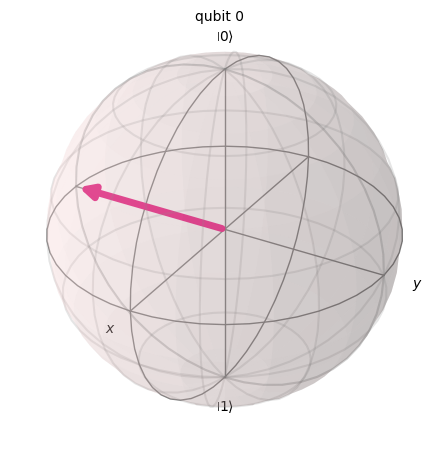

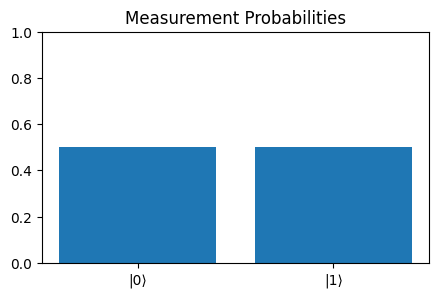

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

# ====================================================
# Change ONLY this value
# Try:
# 0
# np.pi/4
# np.pi/2
# np.pi
# 3*np.pi/2
# ====================================================

theta = np.pi/2

# ====================================================

qc = QuantumCircuit(1)
qc.rx(theta, 0)

state = Statevector.from_instruction(qc)

probs = state.probabilities()

print(f"Theta = {theta:.2f} radians\n")

print(f"P(|0⟩) = {probs[0]:.4f}")
print(f"P(|1⟩) = {probs[1]:.4f}")

display(plot_bloch_multivector(state))

plt.figure(figsize=(5,3))
plt.bar(["|0⟩","|1⟩"], probs)
plt.ylim(0,1)
plt.title("Measurement Probabilities")
plt.show()

Demo 5 – State Collapse

Before measurement, a qubit can exist in a superposition of states. However, once it is measured, the quantum state collapses to a definite classical outcome. In this demo, we'll repeatedly measure a qubit prepared in superposition and observe the randomness of individual measurements.

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

sim = AerSimulator()

for i in range(15):

    qc = QuantumCircuit(1,1)

    qc.h(0)

    qc.measure(0,0)

    result = sim.run(qc, shots=1).result()

    counts = result.get_counts()

    print(f"Measurement {i+1}: {counts}")

Measurement 1: {'0': 1}
Measurement 2: {'1': 1}
Measurement 3: {'0': 1}
Measurement 4: {'1': 1}
Measurement 5: {'0': 1}
Measurement 6: {'1': 1}
Measurement 7: {'1': 1}
Measurement 8: {'0': 1}
Measurement 9: {'0': 1}
Measurement 10: {'0': 1}
Measurement 11: {'1': 1}
Measurement 12: {'0': 1}
Measurement 13: {'0': 1}
Measurement 14: {'0': 1}
Measurement 15: {'1': 1}
